# Project: Action Recognition using CNN + LSTM

In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D,MaxPooling2D,Flatten,LSTM,Dense,Dropout
from tensorflow.keras.utils import to_categorical,plot_model
from tensorflow.keras.optimizers import Adam

2026-03-14 20:28:50.182735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773520130.236531   32664 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773520130.253077   32664 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773520130.311728   32664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773520130.311797   32664 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773520130.311801   32664 computation_placer.cc:177] computation placer alr

In [20]:
#Defining the 18 selected action classes
selected_classes = [
    "Basketball",
    "Diving",
    "HorseRace",
    "JumpRope",
    "VolleyballSpiking",
    "WalkingWithDog",
    "BenchPress",
    "Biking",
    "GolfSwing",
    "HighJump",
    "Kayaking",
    "PullUps",
    "PushUps",
    "RopeClimbing",
    "SkateBoarding",
    "SoccerJuggling",
    "Swing",
    "TrampolineJumping"
    
]

dataset_path = "/kaggle/input/datasets/pypiahmad/realistic-action-recognition-ucf50/UCF50"

for cls in selected_classes:
    print(f"{cls} -> Total Videos:", len(os.listdir(os.path.join(dataset_path,cls))))

Basketball -> Total Videos: 137
Diving -> Total Videos: 153
HorseRace -> Total Videos: 127
JumpRope -> Total Videos: 148
VolleyballSpiking -> Total Videos: 116
WalkingWithDog -> Total Videos: 123
BenchPress -> Total Videos: 160
Biking -> Total Videos: 145
GolfSwing -> Total Videos: 142
HighJump -> Total Videos: 123
Kayaking -> Total Videos: 157
PullUps -> Total Videos: 120
PushUps -> Total Videos: 106
RopeClimbing -> Total Videos: 130
SkateBoarding -> Total Videos: 120
SoccerJuggling -> Total Videos: 156
Swing -> Total Videos: 137
TrampolineJumping -> Total Videos: 119


# EDA - Show Sample Frames from Each Class

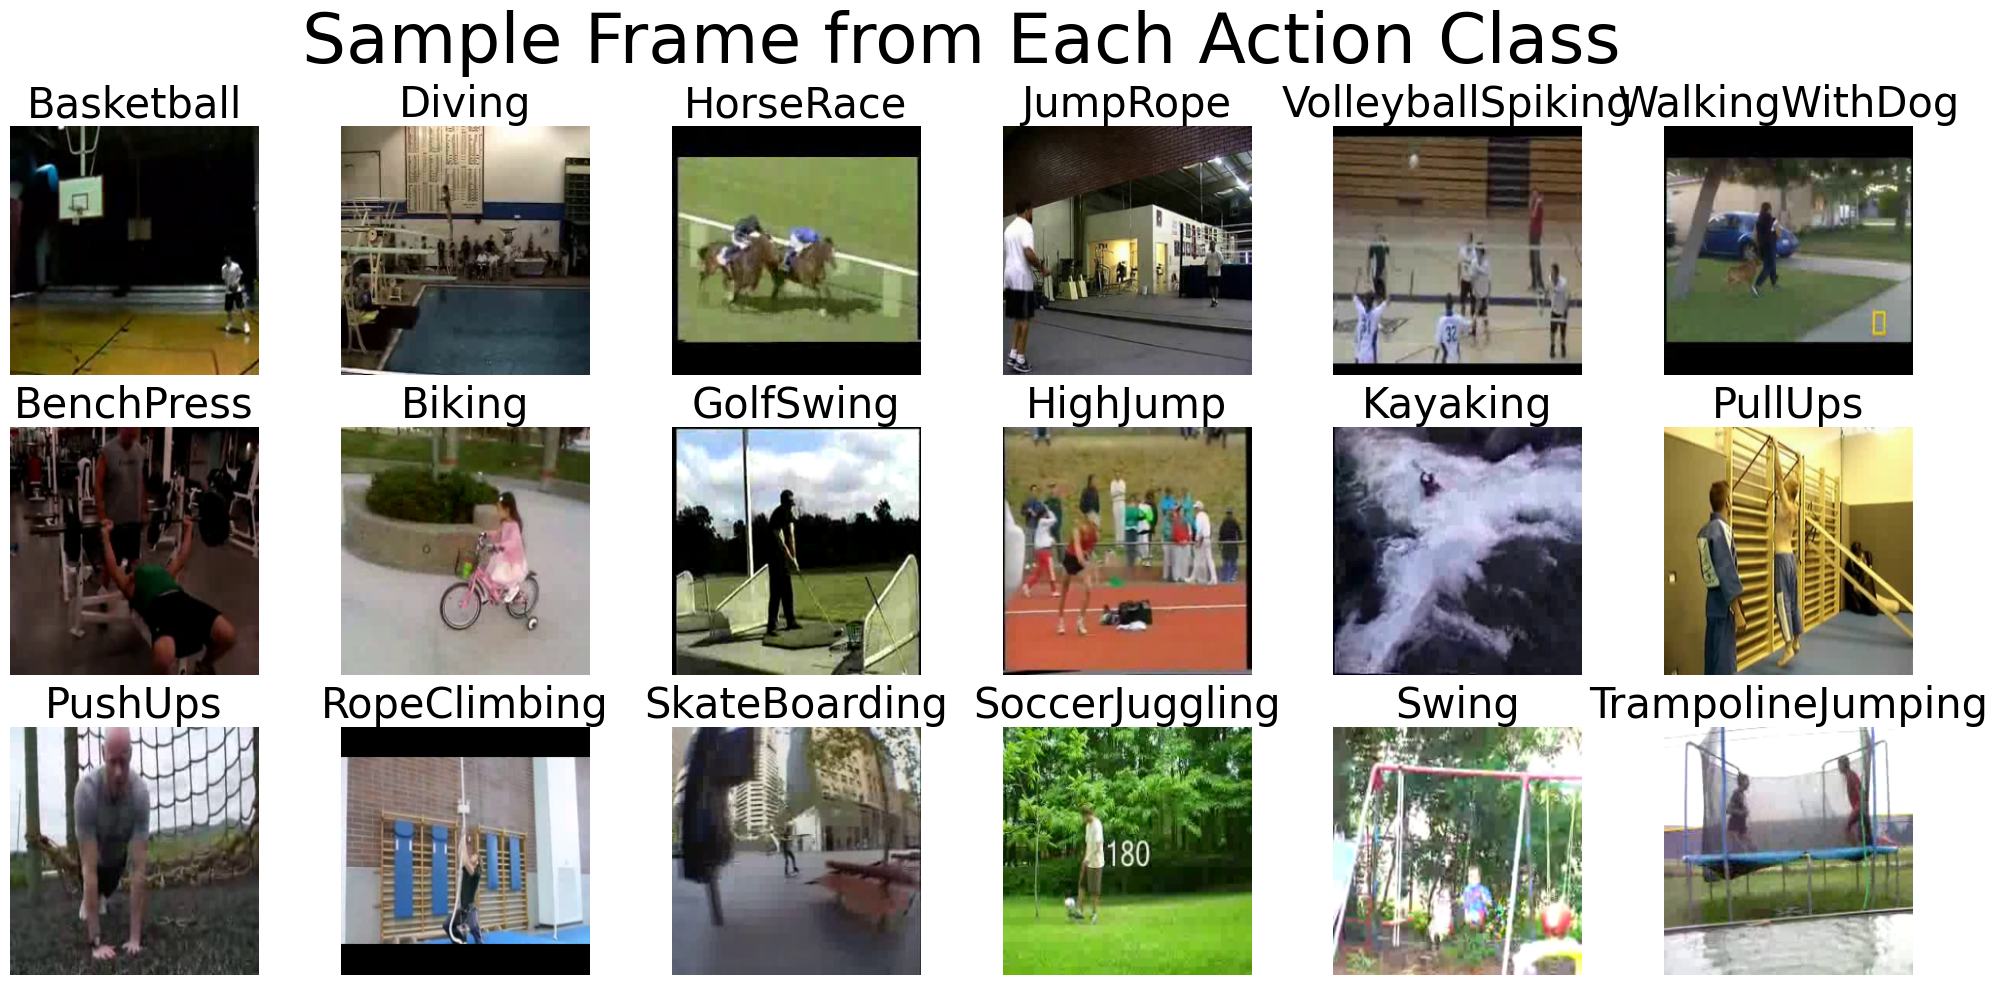

In [21]:
def show_simple_frames(classes , dataset_path):
    fig , axes = plt.subplots(3 , 6 , figsize= (20,10))
    axes = axes.flatten()
    for i , cls in enumerate(classes):
        video_path = os.path.join(dataset_path, cls , os.listdir(os.path.join(dataset_path , cls))[0])
        cap = cv2.VideoCapture(video_path)

        ret , frame = cap.read()
        cap.release()
        if ret:
            frame = cv2.cvtColor(frame , cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame , (256,256))
            axes[i].imshow(frame)
            axes[i].set_title(cls, fontsize = 30)
        axes[i].axis('off')
    plt.suptitle("Sample Frame from Each Action Class" , fontsize= 50)
    plt.tight_layout()
    plt.show()

show_simple_frames(selected_classes , dataset_path)

# Extract Frames from Videos

In [23]:
#  Extract fixed number of frames from each video
# For simplicity and speed, we’ll extract 20 frames per video

def extract_frames(video_path, num_frames=20):
    frames = []
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(total_frames // num_frames, 1)
    
    count = 0
    while len(frames) < num_frames and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if count % frame_interval == 0:
            frame = cv2.resize(frame, (64, 64))
            frame = frame / 255.0  # Normalize pixel values
            frames.append(frame)
        count += 1
    cap.release()

    # Pad with last frame if video too short
    while len(frames) < num_frames:
        frames.append(frames[-1])
    
    return np.array(frames)

# Load Videos and Create Dataset

In [24]:
# Loop through videos in selected classes and extract frames
X = []
y = []

for class_index, cls in enumerate(selected_classes):
    class_path = os.path.join(dataset_path, cls)
    videos = os.listdir(class_path)  

    for video in videos:
        video_path = os.path.join(class_path, video)
        frames = extract_frames(video_path, num_frames=20)
        if frames.shape == (20, 64, 64, 3):  
            X.append(frames)
            y.append(class_index)

X = np.array(X)
y = to_categorical(y) # One-Hot

print(" Data Loaded:")
print("X shape:", X.shape) 
print("y shape:", y.shape)  

 Data Loaded:
X shape: (2419, 20, 64, 64, 3)
y shape: (2419, 18)


# Train-Test Split

In [25]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

print("Training Videos" , X_train.shape[0])
print("Testing Videos", X_test.shape[0])

Training Videos 1935
Testing Videos 484


# Build CNN + LSTM Model with TimeDistributed

In [30]:
model = Sequential()
model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),input_shape=(20,64,64,3)))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu')))
model.add(TimeDistributed(MaxPooling2D(2,2)))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))
model.add(Dropout(0.5))

model.add(Dense(18 , activation = 'softmax'))

model.compile(loss = "categorical_crossentropy" , optimizer = Adam(learning_rate = 0.0005) , metrics = ['accuracy'])

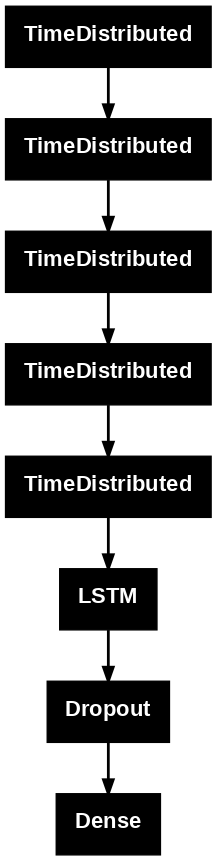

In [31]:
plot_model(model , dpi = 100)

# Train the Model

In [32]:
history = model.fit(X_train, y_train, epochs = 10 , validation_data = (X_test , y_test) , batch_size = 4)

Epoch 1/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 513s 1s/step - accuracy: 0.1174 - loss: 2.8630 - val_accuracy: 0.4318 - val_loss: 2.1176
Epoch 2/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 529s 1s/step - accuracy: 0.4460 - loss: 1.9267 - val_accuracy: 0.5537 - val_loss: 1.5178
Epoch 3/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 528s 1s/step - accuracy: 0.5788 - loss: 1.4181 - val_accuracy: 0.6550 - val_loss: 1.1986
Epoch 4/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 525s 1s/step - accuracy: 0.6638 - loss: 1.1111 - val_accuracy: 0.7521 - val_loss: 0.8813
Epoch 5/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.7802 - loss: 0.7715 - val_accuracy: 0.7603 - val_loss: 0.8058
Epoch 6/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.8417 - loss: 0.5843 - val_accuracy: 0.8079 - val_loss: 0.6739
Epoch 7/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 521s 1s/step - accuracy: 0.8951 - loss: 0.4307 - val_accuracy: 0.7769 - val_loss: 0.7398
Epoch 8/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.9223 - loss: 0.3214 - val_accu

# Plot Accuracy & Loss

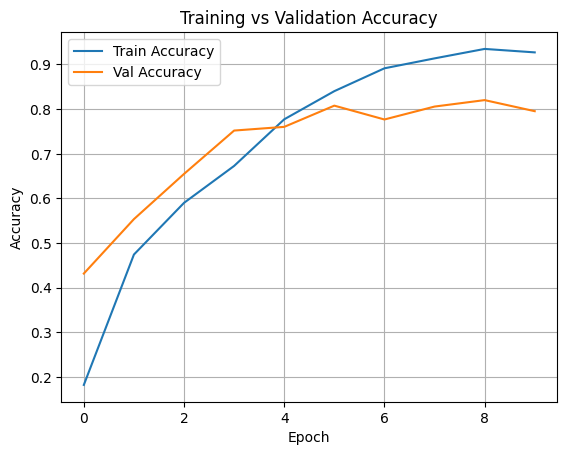

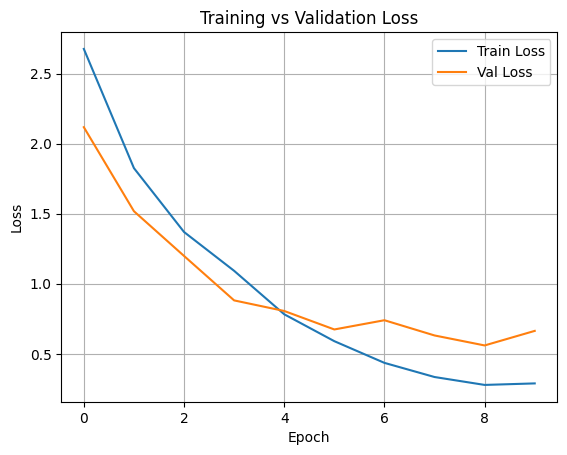

In [33]:
#Training vs Validation Accuracy

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#Training vs Validation Loss
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'], label = 'Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Show Model Predictions on 5 Random Test Videos

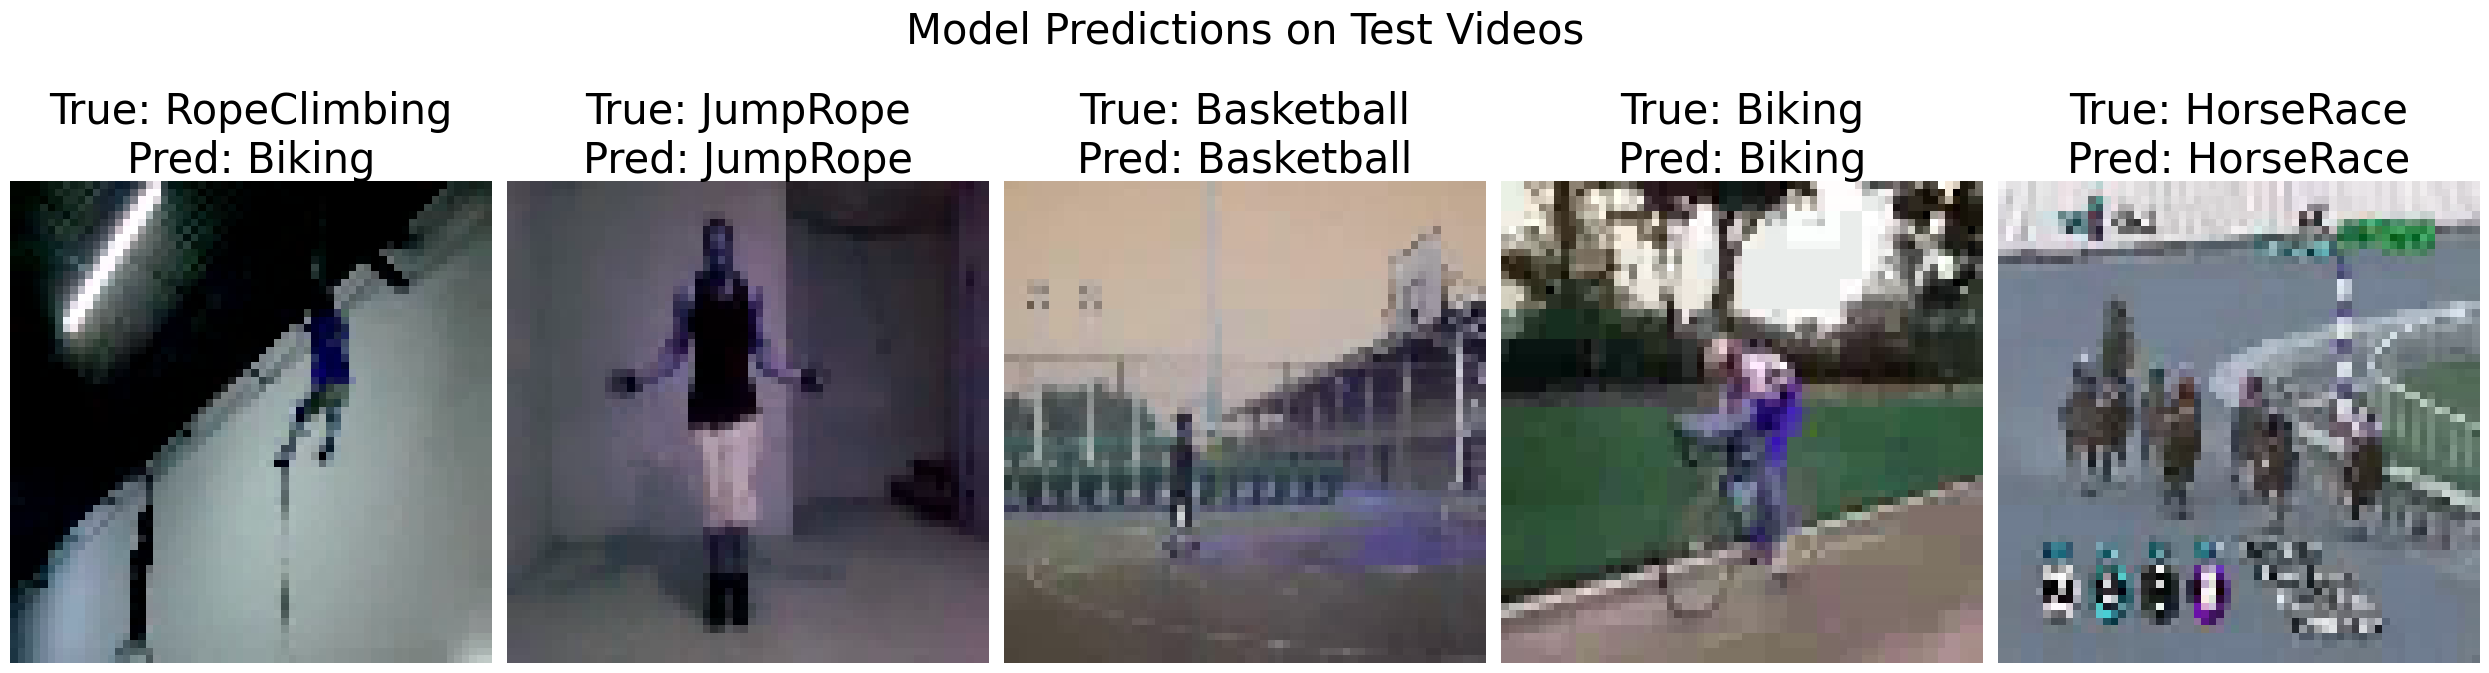

In [34]:
def show_predictions(model, X_test, y_test , class_names):
    indices = np.random.choice(len(X_test), 5 , replace = False)

    fig , axes = plt.subplots(1 , 5 , figsize = (25, 8))
    for i, idx in enumerate(indices):
        video = X_test[idx]
        true_label = class_names[np.argmax(y_test[idx])]

        prediction = model.predict(np.expand_dims(video, axis = 0), verbose = 0)
        predicted_label = class_names[np.argmax(prediction)]

        mid_frame = video[len(video) // 2]
        mid_frame = (mid_frame * 255).astype(np.uint8)

        frame = mid_frame

        axes[i].imshow(frame)
        axes[i].set_title(f"True: {true_label}\nPred: {predicted_label}" , fontsize = 30)
        axes[i].axis('off')
    plt.suptitle("Model Predictions on Test Videos", fontsize = 30)
    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test, selected_classes)